In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.metrics import roc_curve, roc_auc_score
import os
import math

# Training and validation data

In [ ]:
df_val = pd.read_csv(f'../260330_af3_benchmark/Supplementary_Tables/Supplementary_Table_1.csv')[['Epitope', 'TRAV', 'TRAJ', 'cdr3_TRA', 'TRBV', 'TRBJ', 'cdr3_TRB', 'dataset_source', 'Label']]
df_val = df_val.rename(columns={'Epitope' : 'model'})
df_val = df_val[df_val['dataset_source'].isin(['Public TCRs with undetermined specificities', 'Public Paired Data'])]

topir = 'TCR_motif_atlas'

final_epitopes = []
for model, val_group in df_val.groupby('model'):
    if model not in ["A0201_LLWNGPMAV", "A0201_GILGFVFTL"]:
        continue
    if not (model.startswith('A') or model.startswith('B')):
        continue
    if not len(val_group):
        continue
    print(model)
    val_group.to_csv(f'{topir}/{model}/validation.csv', index=False)
    final_epitopes.append(model)

with open(f'{topir}/epitopes.txt', 'w') as f:
    f.write('\n'.join(final_epitopes))

print(f'{len(final_epitopes)} epitopes written to epitopes.txt')

A0201_GILGFVFTL
A0201_LLWNGPMAV
2 epitopes written to epitopes.txt


# ESMfold2 scores

step0 A0201_GILGFVFTL 0.7 2
step1 A0201_GILGFVFTL 0.7 24
step2 A0201_GILGFVFTL 0.7 31
step0 A0201_LLWNGPMAV 0.7 0
step1 A0201_LLWNGPMAV 0.7 9
step2 A0201_LLWNGPMAV 0.7 1


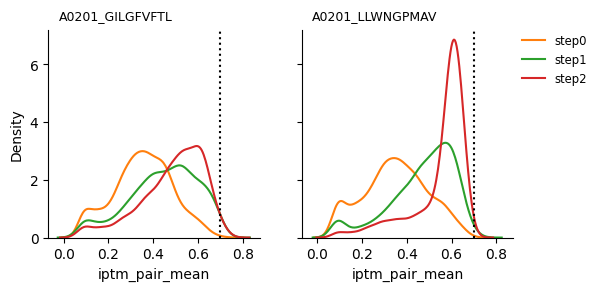

In [4]:
fig, axes = plt.subplots(1,2, figsize=(3*2,2.7), sharex=True, sharey=True)

steps = ['step0', 'step1', 'step2']
peptides = ['A0201_GILGFVFTL', 'A0201_LLWNGPMAV']

# default seaborn/matplotlib palette, skipping the first color (blue)
colors = sns.color_palette()[1:len(steps)+1]


for cnt, peptide in enumerate(peptides):
    ax = axes[cnt]

    for step, color in zip(steps, colors):
        df1 = pd.read_csv(f'TCR_motif_atlas/{peptide}/{step}/output_alpha.csv')[['ID', 'iptm_pair_mean']]
        df2 = pd.read_csv(f'TCR_motif_atlas/{peptide}/{step}/output_beta.csv')[['ID', 'iptm_pair_mean']]
        df = pd.concat([df1, df2])
        sns.kdeplot(df, x='iptm_pair_mean', ax=ax, label=step, color=color)

        #df = pd.read_csv(f'TCR_motif_atlas/{peptide}/{step}/output-beta.csv')[['ID', 'iptm_pair_mean']]
        #sns.kdeplot(df, x='AF3_iptm_pair_mean', ax=ax, label=f'{step} (no prior)', color=color, linestyle=':')
        

        print(step, peptide, 0.7, len(df[df['iptm_pair_mean']>0.7]))

    ax.axvline(x=0.7, color='black', linestyle=':')
    sns.despine()
    ax.text(0.05, 1.05, f'{peptide}', transform=ax.transAxes, fontsize=9)

axes[1].legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0, fontsize='small', frameon=False)

    

step0 A0201_GILGFVFTL 0.7 2
step1 A0201_GILGFVFTL 0.7 14
step0 A0201_LLWNGPMAV 0.7 0
step1 A0201_LLWNGPMAV 0.7 3


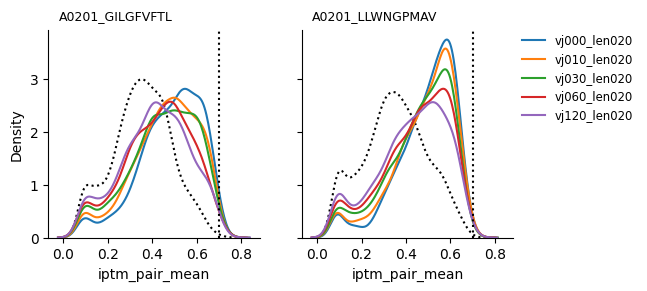

In [5]:
fig, axes = plt.subplots(1,2, figsize=(3*2,2.7), sharex=True, sharey=True)

steps = ['step0', 'step1']
peptides = ['A0201_GILGFVFTL', 'A0201_LLWNGPMAV']
params = ['vj000_len020', 'vj010_len020', 'vj030_len020', 'vj060_len020', 'vj120_len020']

# default seaborn/matplotlib palette, skipping the first color (blue)
colors = sns.color_palette()[1:len(steps)+1]


for cnt, peptide in enumerate(peptides):
    ax = axes[cnt]

    for step, color in zip(steps, colors):
        if step == 'step0':
            df1 = pd.read_csv(f'benchmark/vj000_len020/{peptide}/{step}/output_alpha.csv')[['ID', 'iptm_pair_mean']]
            df2 = pd.read_csv(f'benchmark/vj000_len020/{peptide}/{step}/output_beta.csv')[['ID', 'iptm_pair_mean']]
            df = pd.concat([df1, df2])
            sns.kdeplot(df, x='iptm_pair_mean', ax=ax, color='black', linestyle=':')
        else:
            for p in params:
                df1 = pd.read_csv(f'benchmark/{p}/{peptide}/{step}/output_alpha.csv')[['ID', 'iptm_pair_mean']]
                df2 = pd.read_csv(f'benchmark/{p}/{peptide}/{step}/output_beta.csv')[['ID', 'iptm_pair_mean']]
                df = pd.concat([df1, df2])
                sns.kdeplot(df, x='iptm_pair_mean', ax=ax, label=p)


        print(step, peptide, 0.7, len(df[df['iptm_pair_mean']>0.7]))

    ax.axvline(x=0.7, color='black', linestyle=':')
    sns.despine()
    ax.text(0.05, 1.05, f'{peptide}', transform=ax.transAxes, fontsize=9)

axes[1].legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0, fontsize='small', frameon=False)

    

step0 A0201_GILGFVFTL 0.7 2
step2 A0201_GILGFVFTL 0.7 29
step0 A0201_LLWNGPMAV 0.7 0
step2 A0201_LLWNGPMAV 0.7 4


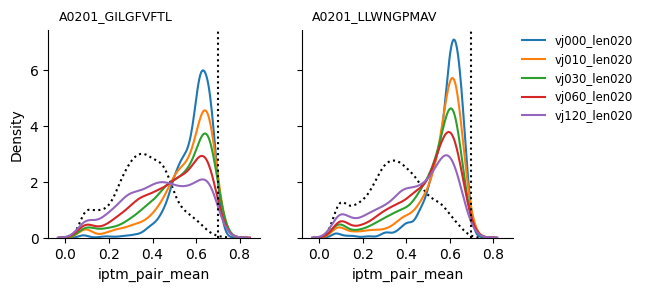

In [6]:
fig, axes = plt.subplots(1,2, figsize=(3*2,2.7), sharex=True, sharey=True)

steps = ['step0', 'step2']
peptides = ['A0201_GILGFVFTL', 'A0201_LLWNGPMAV']
params = ['vj000_len020', 'vj010_len020', 'vj030_len020', 'vj060_len020', 'vj120_len020']

# default seaborn/matplotlib palette, skipping the first color (blue)
colors = sns.color_palette()[1:len(steps)+1]


for cnt, peptide in enumerate(peptides):
    ax = axes[cnt]

    for step, color in zip(steps, colors):
        if step == 'step0':
            df1 = pd.read_csv(f'benchmark/vj000_len020/{peptide}/{step}/output_alpha.csv')[['ID', 'iptm_pair_mean']]
            df2 = pd.read_csv(f'benchmark/vj000_len020/{peptide}/{step}/output_beta.csv')[['ID', 'iptm_pair_mean']]
            df = pd.concat([df1, df2])
            sns.kdeplot(df, x='iptm_pair_mean', ax=ax, color='black', linestyle=':')
        else:
            for p in params:
                df1 = pd.read_csv(f'benchmark/{p}/{peptide}/{step}/output_alpha.csv')[['ID', 'iptm_pair_mean']]
                df2 = pd.read_csv(f'benchmark/{p}/{peptide}/{step}/output_beta.csv')[['ID', 'iptm_pair_mean']]
                df = pd.concat([df1, df2])
                sns.kdeplot(df, x='iptm_pair_mean', ax=ax, label=p)


        print(step, peptide, 0.7, len(df[df['iptm_pair_mean']>0.7]))

    ax.axvline(x=0.7, color='black', linestyle=':')
    sns.despine()
    ax.text(0.05, 1.05, f'{peptide}', transform=ax.transAxes, fontsize=9)

axes[1].legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0, fontsize='small', frameon=False)

    

In [10]:
df = pd.read_csv('benchmark/summary.csv')
df

,vj,len,epitope,step,n_top_a,n_top_b,auc,auc01,fp_gene,fp_share_beta,top_beta_V,top_beta_V_share
0,0,20,A0201_GILGFVFTL,1,168,374,0.696679,0.563203,TRBV25-1,0.305,TRBV19,0.497
1,10,20,A0201_GILGFVFTL,1,143,305,0.747505,0.578636,TRBV25-1,0.315,TRBV19,0.472
2,30,20,A0201_GILGFVFTL,1,145,274,0.724182,0.572917,TRBV25-1,0.255,TRBV19,0.496
3,60,20,A0201_GILGFVFTL,1,108,201,0.753273,0.604845,TRBV25-1,0.264,TRBV19,0.488
4,120,20,A0201_GILGFVFTL,1,87,186,0.743387,0.590844,TRBV25-1,0.124,TRBV19,0.543
5,0,20,A0201_GILGFVFTL,2,114,466,0.749457,0.591779,TRBV25-1,0.182,TRBV19,0.818
6,10,20,A0201_GILGFVFTL,2,95,469,0.761775,0.636234,TRBV25-1,0.203,TRBV19,0.793
7,30,20,A0201_GILGFVFTL,2,89,402,0.780649,0.669437,TRBV25-1,0.174,TRBV19,0.818
8,60,20,A0201_GILGFVFTL,2,40,303,0.782815,0.672098,TRBV25-1,0.234,TRBV19,0.743
9,120,20,A0201_GILGFVFTL,2,39,235,0.782045,0.698132,TRBV25-1,0.136,TRBV19,0.851


In [35]:
epitopes = ['A0201_GILGFVFTL', 'A0201_LLWNGPMAV']

for epitope in epitopes:
    #df = pd.read_csv('benchmark/summary.csv')
    df = pd.read_csv('test/summary_top50.csv')

    df = df[df['epitope'] == epitope]
    print(epitope)
    df_step = df[df['step'] == 1]
    df_step = df_step.groupby(['vj'])[['auc', 'auc01']].mean().reset_index()
    print("step 1") 
    print(df_step)
    df_step = df[df['step'] == 2]
    df_step = df_step.groupby(['vj'])[['auc', 'auc01']].mean().reset_index()
    print("step 2")
    print(df_step)

A0201_GILGFVFTL
step 1
    vj       auc     auc01
0    0  0.754567  0.599343
1   10  0.777758  0.650072
2   30  0.764972  0.617170
3   60  0.773968  0.660499
4  120  0.754852  0.626029
step 2
    vj       auc     auc01
0    0  0.754546  0.591747
1   10  0.773274  0.649262
2   30  0.771354  0.634273
3   60  0.776611  0.667345
4  120  0.772662  0.649397
A0201_LLWNGPMAV
step 1
    vj       auc     auc01
0    0  0.865770  0.744376
1   10  0.856619  0.757159
2   30  0.865210  0.752276
3   60  0.867758  0.773249
4  120  0.873686  0.752158
step 2
    vj       auc     auc01
0    0  0.824675  0.749588
1   10  0.862571  0.765550
2   30  0.851997  0.775112
3   60  0.870528  0.789184
4  120  0.858308  0.732614


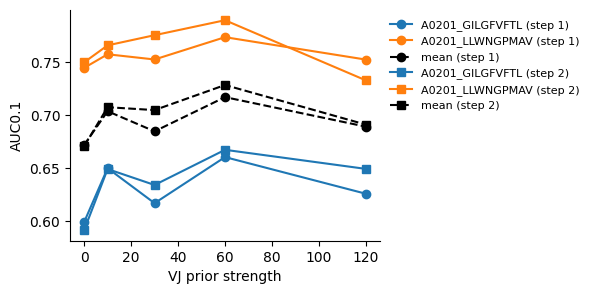

In [38]:
#df = pd.read_csv('benchmark/summary.csv')
df = pd.read_csv('test/summary_top50.csv')

# marker per step, consistent across the whole figure
step_markers = {1: 'o', 2: 's'}   # add more if you have more steps

fig, ax = plt.subplots(figsize=(4, 3))

# stable color per epitope, shared across steps
epitopes = sorted(df['epitope'].unique())
colors = dict(zip(epitopes, plt.cm.tab10.colors))

for step, marker in step_markers.items():
    d = (df[df['step'] == step]
         .groupby(['vj', 'epitope'])[['auc', 'auc01']]
         .mean()
         .reset_index()
         .sort_values('vj'))

    # one colored line per epitope
    for epi in epitopes:
        sub = d[d['epitope'] == epi].sort_values('vj')
        if sub.empty:
            continue
        ax.plot(sub['vj'], sub['auc01'],
                marker=marker, color=colors[epi],
                label=f'{epi} (step {step})')

    # black dashed = mean across epitopes for this step
    mean_line = d.groupby('vj')['auc01'].mean().reset_index().sort_values('vj')
    ax.plot(mean_line['vj'], mean_line['auc01'],
            marker=marker, color='black', linestyle='--',
            label=f'mean (step {step})')

ax.set_xlabel('VJ prior strength')          # <- replace with a meaningful label
ax.set_ylabel('AUC0.1')
ax.legend(fontsize=8, bbox_to_anchor=(1,1), frameon=False)
sns.despine()

# AUC

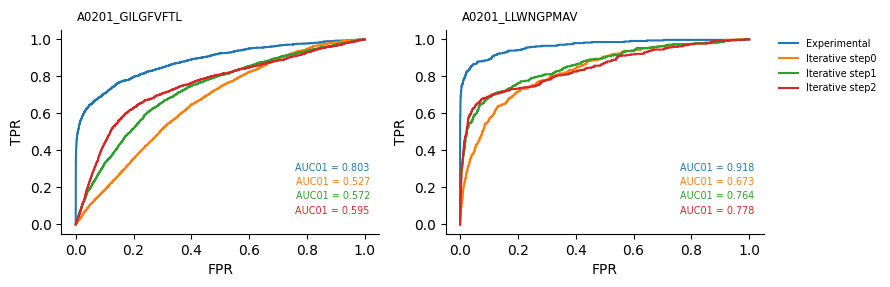

In [5]:
epitopes = ['A0201_GILGFVFTL', 'A0201_LLWNGPMAV']
steps = ['step0', 'step1', 'step2']

fig, axes = plt.subplots(1, len(epitopes), figsize=(9, 3))

for cnt, epitope in enumerate(epitopes):
    ax = axes[cnt]
    ax.text(0.05, 1.1, epitope, transform=ax.transAxes,
            va='top', ha='left', fontsize='small')

    # --- Experimental curve ---
    df = pd.read_csv(
        f'../260512_TEMPO_motif_builder_test/{epitope}/TEMPO_train_exp.csv'
    )
    y_true, y_scores = df['Label'].values, df['score'].values
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    auc01 = roc_auc_score(y_true, y_scores, max_fpr=0.1)
    line, = ax.plot(fpr, tpr, label='Experimental')
    ax.text(0.97, 0.3, f"AUC01 = {auc01:.3f}",
            transform=ax.transAxes, ha='right', va='bottom',
            fontsize='x-small', color=line.get_color())

    # --- One curve per step ---
    for i, s in enumerate(steps):
        df = pd.read_csv(
            f'TCR_motif_atlas/{epitope}/{s}/validation/validation_pred.csv'
        )
        y_true, y_scores = df['Label'].values, df['score'].values
        fpr, tpr, _ = roc_curve(y_true, y_scores)
        auc01 = roc_auc_score(y_true, y_scores, max_fpr=0.1)
        line, = ax.plot(fpr, tpr, label=f'Iterative {s}')
        ax.text(0.97, 0.23 - i * 0.07, f"AUC01 = {auc01:.3f}",
                transform=ax.transAxes, ha='right', va='bottom',
                fontsize='x-small', color=line.get_color())

    ax.set_xlabel('FPR')
    ax.set_ylabel('TPR')

handles, labels = axes[-1].get_legend_handles_labels()
axes[-1].legend(handles, labels, fontsize='x-small', frameon=False,
                bbox_to_anchor=(1.02, 1), loc='upper left')

sns.despine()
plt.tight_layout()
plt.show()




In [14]:
step = 2
df = pd.read_csv(f'bck.TCR_motif_atlas.260706/A0201_GILGFVFTL/step{step}/top_tcrs_beta.csv')
df = df.sort_values(by='iptm_pair_mean', ascending=False)
df

df = df[df['TRBV'] == 'TRBV25-1']
df

,id,TRBV,TRBJ,cdr3_TRB,TRAV,TRAJ,cdr3_TRA,peptide,MHC,species,iptm_pair_mean
42,tcr0087,TRBV25-1,TRBJ1-2,CASSPYGWQGYTF,TRAV38-2/DV8_dummy,TRAJ43,CGGGGGGGGGGF,GILGFVFTL,HLA_A0201,HomoSapiens,0.7219
150,tcr0422,TRBV25-1,TRBJ1-4,CASSGIGTPDEKLFF,TRAV38-2/DV8_dummy,TRAJ43,CGGGGGGGGGGF,GILGFVFTL,HLA_A0201,HomoSapiens,0.7122
159,tcr0458,TRBV25-1,TRBJ2-1,CASSQVEKQFF,TRAV38-2/DV8_dummy,TRAJ43,CGGGGGGGGGGF,GILGFVFTL,HLA_A0201,HomoSapiens,0.7090
436,tcr1124,TRBV25-1,TRBJ1-5,CASILCDSQHF,TRAV38-2/DV8_dummy,TRAJ43,CGGGGGGGGGGF,GILGFVFTL,HLA_A0201,HomoSapiens,0.7073
93,tcr0228,TRBV25-1,TRBJ2-1,CASQSATGNEQFF,TRAV38-2/DV8_dummy,TRAJ43,CGGGGGGGGGGF,GILGFVFTL,HLA_A0201,HomoSapiens,0.7061
...,...,...,...,...,...,...,...,...,...,...,...
389,tcr1007,TRBV25-1,TRBJ1-5,CASSLSNSNQPQHF,TRAV38-2/DV8_dummy,TRAJ43,CGGGGGGGGGGF,GILGFVFTL,HLA_A0201,HomoSapiens,0.6512
241,tcr0665,TRBV25-1,TRBJ1-5,CASSRIGGGSQPQHF,TRAV38-2/DV8_dummy,TRAJ43,CGGGGGGGGGGF,GILGFVFTL,HLA_A0201,HomoSapiens,0.6512
304,tcr0794,TRBV25-1,TRBJ2-7,CASSSVGSDADEQYF,TRAV38-2/DV8_dummy,TRAJ43,CGGGGGGGGGGF,GILGFVFTL,HLA_A0201,HomoSapiens,0.6508
429,tcr1101,TRBV25-1,TRBJ1-2,CASSPGGAGGYTF,TRAV38-2/DV8_dummy,TRAJ43,CGGGGGGGGGGF,GILGFVFTL,HLA_A0201,HomoSapiens,0.6506
